In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Methodology
1. Data preprocessing
2. Train-test split
3. Model training
4. Standard Scaling
5. Model Evaluation
6. Model comparision

In [2]:
data= pd.read_csv('train.csv')
data.shape

(21263, 82)

In [3]:
data.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [4]:
data.duplicated().sum()

np.int64(66)

In [5]:
df = data.drop_duplicates()

In [6]:
df.shape

(21197, 82)

In [7]:
from sklearn.model_selection  import train_test_split
X= df.drop('critical_temp',axis  =1).values
y = df['critical_temp'].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)


In [9]:
 from  sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()
scaled_X_train= scaler.fit_transform(X_train)

df_feat_X_train = pd.DataFrame(scaled_X_train,columns=df.columns[:-1])

In [10]:
df_feat_X_train.head().shape

(5, 81)

In [11]:
X_test_scaled=  scaler.transform(X_test)
df_feat_Xtest = pd.DataFrame(X_test_scaled,columns=df.columns[:-1])
df_feat_Xtest.shape

(6360, 81)

In [12]:
from tensorflow.keras.models  import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout,Input

In [76]:

model = Sequential()
model.add(Input(shape=(scaled_X_train.shape[1],)))
model.add(Dense(128, activation='relu', ))

model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer = 'Adam', loss  = 'mse')



In [77]:
model.fit(df_feat_X_train,y_train,validation_split=0.3,epochs = 250, batch_size=32, verbose =0)

In [78]:
loss_df  = pd.DataFrame(model.history.history)

<Axes: >

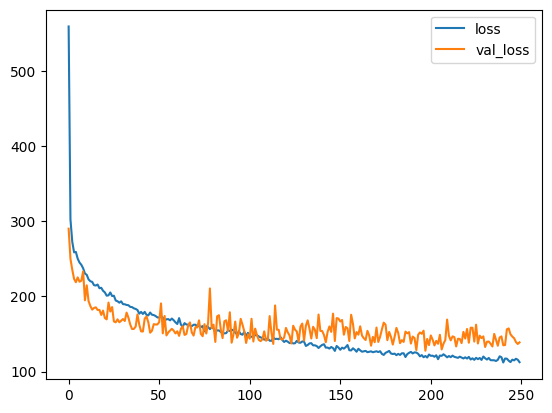

In [79]:
loss_df.plot()

The training and validation loss curves show a steady decrease, indicating that the neural network successfully learns the underlying patterns in the data. The validation loss stabilizes after initial epochs with minor fluctuations, suggesting good generalization. A small gap between training and validation loss indicates slight overfitting, but it remains within acceptable limits

In [60]:
model.evaluate(df_feat_Xtest,y_test,verbose= 0)

129.4681854248047

In [61]:
model.evaluate(df_feat_X_train,y_train,verbose= 0)

96.0341796875

In [62]:
test_predictions=model.predict(df_feat_Xtest)

test_predictions=  pd.Series(test_predictions.reshape(6360,))




199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [63]:
test_predictions =pd.DataFrame(test_predictions,columns =['Test True Y'])

In [64]:
pred_df= pd.DataFrame(y_test,columns =['Test True Y'])

In [65]:
pred_df= pd.concat([pred_df,test_predictions],axis =1)
pred_df

,Test True Y,Test True Y
0,81.0,77.668091
1,10.0,15.430792
2,5.5,4.602532
3,26.5,65.729996
4,82.5,83.787659
...,...,...
6355,78.7,75.906960
6356,30.5,22.475840
6357,5.7,3.755361
6358,5.7,4.519559


In [66]:
pred_df.columns=  ['Test True Y', 'Model Predictions']

In [67]:
pred_df

,Test True Y,Model Predictions
0,81.0,77.668091
1,10.0,15.430792
2,5.5,4.602532
3,26.5,65.729996
4,82.5,83.787659
...,...,...
6355,78.7,75.906960
6356,30.5,22.475840
6357,5.7,3.755361
6358,5.7,4.519559


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

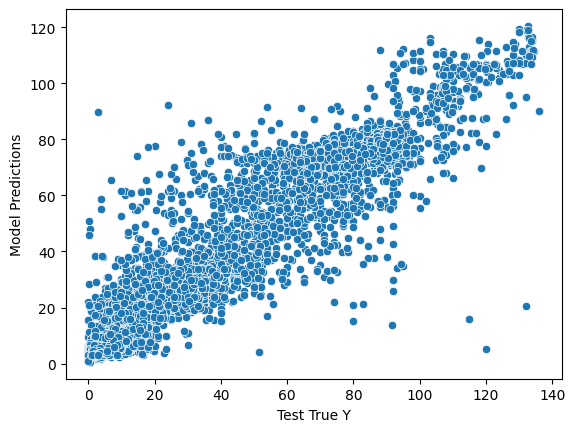

In [68]:
sns.scatterplot(x= 'Test True Y' ,y =  'Model Predictions' ,data = pred_df)

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [70]:
mean_absolute_error(pred_df['Test True Y'],pred_df['Model Predictions'])

7.308898757097046

In [71]:
mean_squared_error(pred_df['Test True Y'],pred_df['Model Predictions'])

129.46824093811642

In [72]:
r2_score(pred_df['Test True Y'],pred_df['Model Predictions'])

0.8901303277361916

# kNN Algorithm

In [30]:
from sklearn.neighbors import KNeighborsRegressor

In [31]:
KNN_model = KNeighborsRegressor(n_neighbors=2)

In [32]:
KNN_model.fit(scaled_X_train,y_train)
KNN_predictions = KNN_model.predict(X_test_scaled)

Text(0, 0.5, 'Error Rate')

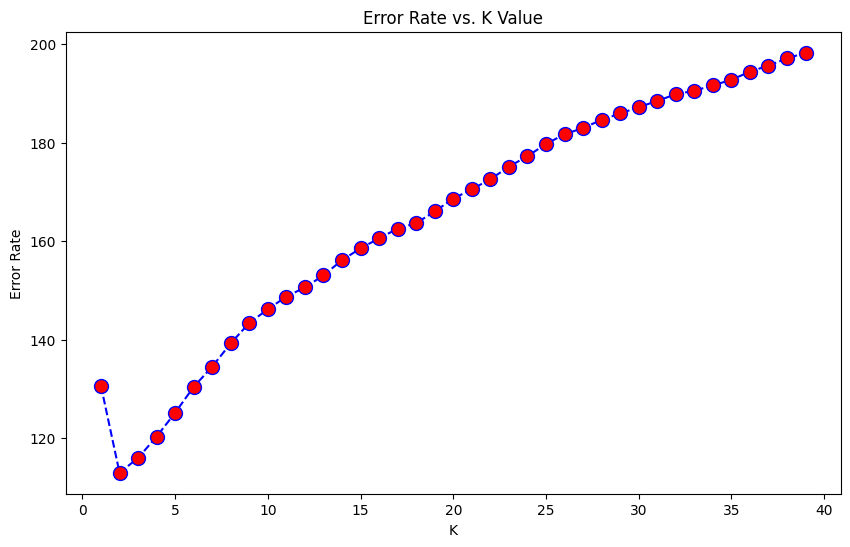

In [33]:
error= []

for i in range(1,40):
  KNN_model_i = KNeighborsRegressor(n_neighbors=i)
  KNN_model_i.fit(scaled_X_train,y_train)
  pred_i = KNN_model_i.predict(X_test_scaled)
  error.append(mean_squared_error(y_test, pred_i))



plt.figure(figsize=(10,6))
plt.plot(range(1,40),error,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')


This graphs shows that k =2 is the best value.

In [73]:
print('MAE:', mean_absolute_error(y_test, KNN_predictions))
print('MSE:', mean_squared_error(y_test, KNN_predictions))
print('RMSE:', np.sqrt(mean_squared_error(y_test, KNN_predictions)))
print('r^2:', r2_score(y_test, KNN_predictions))

MAE: 5.603292873427673
MSE: 113.00670010272928
RMSE: 10.630460954386187
r^2: 0.9040999629412129


In [74]:
results  =  {'Model': ['Neural Network','KNN'],
             "r2":[r2_score(pred_df['Test True Y'],pred_df['Model Predictions']), r2_score(y_test, KNN_predictions)],
             "MAE":[mean_absolute_error(pred_df['Test True Y'],pred_df['Model Predictions']),mean_absolute_error(y_test, KNN_predictions)],
             "MSE":[mean_squared_error(pred_df['Test True Y'],pred_df['Model Predictions']),mean_squared_error(y_test, KNN_predictions)]}

In [75]:
df_results=  pd.DataFrame(results)
df_results

,Model,r2,MAE,MSE
0,Neural Network,0.89013,7.308899,129.468241
1,KNN,0.90410,5.603293,113.006700


KNN and neural network models were applied to predict superconducting critical temperature (Tc). The KNN model demonstrated slightly better by achieving lower
MSE and RMSE along with higher R² values. This suggests that KNN effectively captures local relationships in the data. In contrast, the neural network showed slightly lower performance, possibly due to limited data or insufficient tuning. Overall, KNN proved to be more suitable for this dataset.